In [1]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
from pathlib import Path
import sys

current = Path.cwd().resolve()

for parent in [current] + list(current.parents):
    if (parent / "src").exists():
        PROJECT_ROOT = parent
        SRC_PATH = parent / "src"
        break
else:
    raise FileNotFoundError("Cannot find project root with src folder.")


for path in [PROJECT_ROOT, SRC_PATH]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

print("Project root:", PROJECT_ROOT)
print("Src path:", SRC_PATH)

import config
import transforms

print("config imported from:", config.__file__)
print("transforms imported from:", transforms.__file__)




Project root: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1
Src path: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\src
config imported from: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\src\config.py
transforms imported from: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\src\transforms.py


In [3]:
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from src.config import (
    DEVICE,
    NUM_EPOCHS,
    RANDOM_SEED,
    MODEL_DIR,
    RESULT_DIR,
    FIGURE_DIR,
    CLASS_NAMES,
)

from src.dataset import get_dataloaders
from src.metrics import calculate_classification_metrics
from src.transfer_models_DenseNet.densenet121_model import get_densenet121

MODEL_NAME = "densenet121"
LEARNING_RATE = 0.0001
PATIENCE = 5

print("Device from config:", DEVICE)
print("Number of epochs:", NUM_EPOCHS)
print("Classes:", CLASS_NAMES)




Device from config: cuda
Number of epochs: 20
Classes: ['Normal', 'Doubtful', 'Mild', 'Moderate', 'Severe']


In [4]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device(DEVICE)

print("Using device:", device)




Using device: cuda


In [5]:
train_loader, val_loader, test_loader = get_dataloaders()

print("DataLoader info:")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")




DataLoader info:
Train batches: 64
Validation batches: 10
Test batches: 19


rennet model

In [6]:
train_loader, val_loader, test_loader = get_dataloaders()

print("DataLoader info:")
print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")




DataLoader info:
Train batches: 64
Validation batches: 10
Test batches: 19


densenet + ordinal aware loss

In [7]:
# DenseNet121 + Ordinal-aware Loss
import torch.nn.functional as F

MODEL_VERSION = "densenet121_ordinal_loss"
LEARNING_RATE = 0.0001
PATIENCE = 5

NUM_CLASSES = len(CLASS_NAMES)
ORDINAL_ALPHA = 0.5

model = get_densenet121(
    pretrained=True,
    fine_tune_last_block=True
).to(device)


class OrdinalAwareLoss(nn.Module):
    """
    Ordinal-aware loss for KL grade classification.

    It combines:
    1. CrossEntropyLoss for correct class prediction
    2. Ordinal penalty for distance between predicted grade and true grade

    Loss = CE Loss + alpha * ordinal distance penalty
    """

    def __init__(self, num_classes=5, alpha=0.5):
        super().__init__()
        self.num_classes = num_classes
        self.alpha = alpha

    def forward(self, logits, targets):
        # Standard classification loss
        ce_loss = F.cross_entropy(
            logits,
            targets,
            reduction="none"
        )

        # Convert logits to probabilities
        probs = F.softmax(logits, dim=1)

        # Class indices: [0, 1, 2, 3, 4]
        class_indices = torch.arange(
            self.num_classes,
            device=logits.device,
            dtype=torch.float32
        )

        # Expected predicted grade
        expected_grade = torch.sum(probs * class_indices, dim=1)

        # Distance between expected grade and true grade
        ordinal_penalty = torch.abs(expected_grade - targets.float())

        # Combine CE and ordinal penalty
        loss = ce_loss + self.alpha * ordinal_penalty

        return loss.mean()


criterion = OrdinalAwareLoss(
    num_classes=NUM_CLASSES,
    alpha=ORDINAL_ALPHA
).to(device)

trainable_params = filter(lambda p: p.requires_grad, model.parameters())

optimizer = optim.Adam(
    trainable_params,
    lr=LEARNING_RATE
)

print("=" * 50)
print("DenseNet121 + Ordinal-aware Loss")
print("=" * 50)

total_params = sum(p.numel() for p in model.parameters())
trainable_params_count = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params_count:,}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Early stopping patience: {PATIENCE}")
print(f"Ordinal alpha: {ORDINAL_ALPHA}")



DenseNet121 + Ordinal-aware Loss
Total parameters: 6,958,981
Trainable parameters: 2,165,253
Learning rate: 0.0001
Early stopping patience: 5
Ordinal alpha: 0.5


In [8]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, dim=1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def evaluate_one_epoch(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc




In [9]:
best_val_loss = float("inf")
best_val_acc = 0.0
epochs_without_improvement = 0

best_model_path = MODEL_DIR / f"{MODEL_VERSION}_best.pth"

history = {
    "epoch": [],
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

start_time = time.time()

print("=" * 50)
print("Training DenseNet121 + Ordinal-aware Loss")
print("=" * 50)
print(f"Device: {device}")
print(f"Epochs: {NUM_EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Ordinal alpha: {ORDINAL_ALPHA}")

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(
        model=model,
        train_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    val_loss, val_acc = evaluate_one_epoch(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        device=device
    )

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch}/{NUM_EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_val_acc = val_acc
        epochs_without_improvement = 0

        torch.save(model.state_dict(), best_model_path)
        print(f"Best model saved: {best_model_path}")
    else:
        epochs_without_improvement += 1
        print(f"No improvement: {epochs_without_improvement}/{PATIENCE}")

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

end_time = time.time()
training_time = end_time - start_time

history_df = pd.DataFrame(history)
history_path = RESULT_DIR / f"{MODEL_VERSION}_training_history.csv"
history_df.to_csv(history_path, index=False)

print("\n" + "=" * 50)
print("Training finished")
print("=" * 50)
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Best validation accuracy: {best_val_acc:.4f}")
print(f"Epochs trained: {len(history['epoch'])}")
print(f"Training time: {training_time:.2f} seconds")
print(f"History saved to: {history_path}")
print(f"Best model saved to: {best_model_path}")




Training DenseNet121 + Ordinal-aware Loss
Device: cuda
Epochs: 20
Learning rate: 0.0001
Ordinal alpha: 0.5
Epoch [1/20] Train Loss: 1.7742 | Train Acc: 0.4521 | Val Loss: 1.3045 | Val Acc: 0.6233
Best model saved: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\models\densenet121_ordinal_loss_best.pth
Epoch [2/20] Train Loss: 1.2770 | Train Acc: 0.6475 | Val Loss: 1.0975 | Val Acc: 0.6986
Best model saved: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\models\densenet121_ordinal_loss_best.pth
Epoch [3/20] Train Loss: 1.0514 | Train Acc: 0.7148 | Val Loss: 0.9662 | Val Acc: 0.7192
Best model saved: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\models\densenet121_ordinal_loss_best.pth
Epoch [4/20] Train Loss: 0.8853 | Train Acc: 0.7676 | Val Loss: 0.8872 | Val Acc: 0.7260
Best model saved: C:\Users\Lv043\OneDrive\Desktop\760proj\760-Group1\outputs\models\densenet121_ordinal_loss_best.pth
Epoch [5/20] Train Loss: 0.8224 | Train Acc: 0.7695 | Val Loss: 0

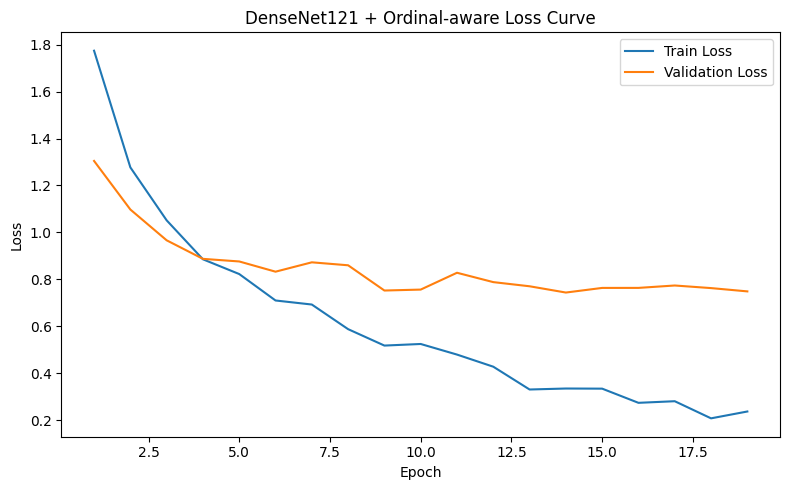

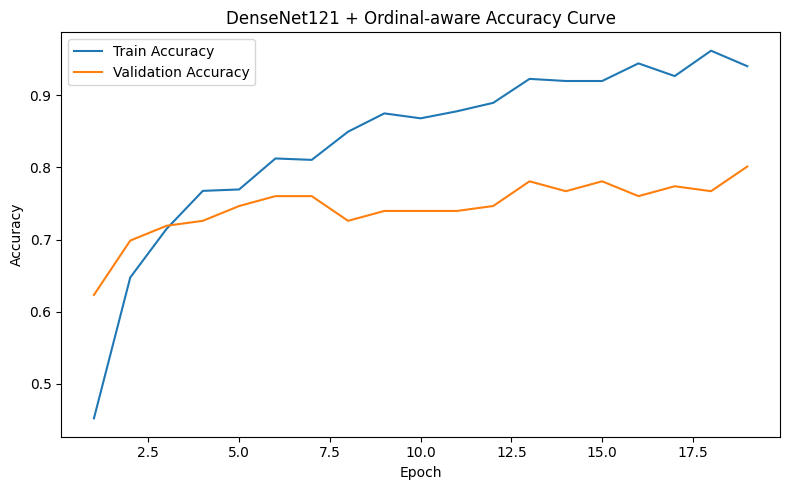

In [10]:
epochs = history["epoch"]

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DenseNet121 + Ordinal-aware Loss Curve")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("DenseNet121 + Ordinal-aware Accuracy Curve")
plt.legend()
plt.tight_layout()
plt.show()




Evaluating DenseNet121 + Ordinal-aware Loss on Test Set


C:\Users\Lv043\AppData\Local\Temp\ipykernel_32640\3736833326.py:41: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test_model.load_state_dict(torch.load(model_path, map_locat


Overall Test Metrics:
accuracy: 0.7279
macro_f1: 0.7182
weighted_f1: 0.7265
mae: 0.3741
qwk: 0.8294
total_errors: 80
adjacent_errors: 59
distant_errors: 21
adjacent_error_rate_among_errors: 0.7375
distant_error_rate_among_errors: 0.2625

Per-Class Metrics:


,label,class_name,precision,recall,f1_score,support
0,0,Normal,0.768421,0.802198,0.784946,91
1,1,Doubtful,0.684783,0.715909,0.700000,88
2,2,Mild,0.611111,0.578947,0.594595,38
3,3,Moderate,0.731707,0.857143,0.789474,35
4,4,Severe,0.866667,0.619048,0.722222,42


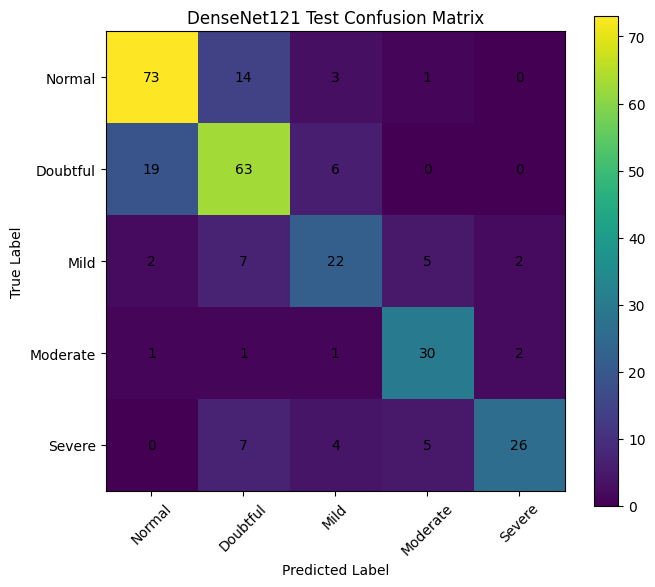

In [11]:
def predict(model, data_loader, device):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    softmax = torch.nn.Softmax(dim=1)

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)

            outputs = model(images)
            probs = softmax(outputs)
            _, preds = torch.max(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())

    return all_labels, all_preds, all_probs


print("=" * 50)
print("Evaluating DenseNet121 + Ordinal-aware Loss on Test Set")
print("=" * 50)

model_path = MODEL_DIR / "densenet121_ordinal_loss_best.pth"

if not model_path.exists():
    raise FileNotFoundError(
        f"Cannot find model file: {model_path}. Please run Cell 7 training first."
    )

test_model = get_densenet121(
    pretrained=False,
    fine_tune_last_block=True
).to(device)

test_model.load_state_dict(torch.load(model_path, map_location=device))

# test set predict
y_true, y_pred, y_probs = predict(
    model=test_model,
    data_loader=test_loader,
    device=device
)

overall_metrics, per_class_metrics, cm = calculate_classification_metrics(
    y_true=y_true,
    y_pred=y_pred,
    class_names=CLASS_NAMES
)

print("\nOverall Test Metrics:")
for key, value in overall_metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

print("\nPer-Class Metrics:")
per_class_df = pd.DataFrame(per_class_metrics)
display(per_class_df)

plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("DenseNet121 Test Confusion Matrix")
plt.colorbar()

tick_marks = range(len(CLASS_NAMES))
plt.xticks(tick_marks, CLASS_NAMES, rotation=45)
plt.yticks(tick_marks, CLASS_NAMES)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            horizontalalignment="center",
            verticalalignment="center"
        )

plt.tight_layout()
plt.show()


